In [2]:
import os
import mat73
import pandas as pd
import numpy as np
import sys
import json
import pickle
sys.path.append("..")
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from scipy.stats import spearmanr
from nilearn import plotting
from src.decomposition import CompoThr
from src.setting import GetInfo, PROJECT_PATH
from src.config import COL_REG, col_pc

In [3]:
ieeg_datapath = 'ieeg_shortWOBS_fs250'
meg_datapath = '/projects/MINDLAB2025_MEG-Auditory_Cognitive_Maps/scratch/APR2020_Block3_SingleTrial_BarbaraNikita'
meg_outpath ='MEG/dataMEG'

os.path.isdir(meg_datapath)
meg_subj_list = [file.replace('_sensor.p', '') for file in os.listdir(meg_outpath) if '_sensor' in file]
print('MEG Subject number : ', len(meg_subj_list))

ieeg_subj_list = [file.replace('_epochs.p', '') for file in os.listdir(ieeg_datapath) if file[-len('epochs.p'):] == 'epochs.p']
print('iEEG Subject number : ', len(ieeg_subj_list))

info_file = ieeg_datapath + f'/{ieeg_subj_list[0]}_info.json'
with open(info_file) as json_data:
    d = json.load(json_data)
    time_ieeg = d['time_epoch']

project_path = '../' + PROJECT_PATH
coord, areas, elect_list, subj_list, regions_ieeg = GetInfo(ieeg_subj_list, data_path=ieeg_datapath, project_path=project_path)
coord=np.array(coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = coord/1000

MEG Subject number :  32
iEEG Subject number :  30


In [4]:
from utils import match_meg, mask_meg, get_region_label, structure_coefficients, update_COL_REG, get_meg_data

In [6]:
out_path = 'out/data'

with open(out_path + '/ieeg_data_mean.p', "rb") as f:
    ieeg_data = pickle.load(f)

with open(out_path + '/data_matched.p', "rb") as f:
    data_matched = pickle.load(f)      

In [7]:
data_matched = data_matched.mean(0)

## Get the regions

In [8]:
pos = pd.read_csv('/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/MEG/dataMEG/SUBJ_0002_pos.csv').drop(columns='Unnamed: 0')
#mask = mask_meg(pos, coord, radius_1=r, return_mask=True, show=False) # mask area not covered
#pos_m = pos[mask] 
pos_match=[]

meg_data_source = get_meg_data(meg_outpath, meg_subj_list)
mask_match = match_meg(meg_data_source, ieeg_subj_list, coord, meg_subj_list, subj_list, return_mask=True )
for s in mask_match.keys() : 
    pos_s = pd.read_csv(f'/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/MEG/dataMEG/{s}_pos.csv').drop(columns='Unnamed: 0')
    pos_match.append(pos_s.loc[mask_match[s], :])
pos_match = pd.concat(pos_match)

#regions_meg_m = get_region_label(pos_m)
regions_meg = get_region_label(pos)
regions_meg_match=get_region_label(pos_match)

all_regions = sorted(set(regions_meg_match) | set(regions_ieeg))
COL_REG = update_COL_REG(col_reg=COL_REG,all_regions=all_regions)

[fetch_atlas_aal] Dataset found in /users/barbara/nilearn_data/aal_SPM12

[fetch_atlas_aal] Dataset found in /users/barbara/nilearn_data/aal_SPM12

In [9]:
regions_commun  = regions_ieeg + regions_meg_match*32
regions_commun_color = [COL_REG[r] for r in regions_commun]

In [55]:
# get labels
df_label  =pd.read_csv('out/labels/labels_Kmean_singlePC3.csv').drop(columns = ['Unnamed: 0'])
df_label_meg  =pd.read_csv('out/labels/labels_Kmean_MEG_match_pc.csv').drop(columns = ['Unnamed: 0'])

gradient = plt.cm.rainbow(np.linspace(0, 1, ieeg_data.mean(0).shape[0]))
sorted_idx = np.argsort(np.linalg.norm(coord, axis=1)) 
sorted_idx = [r_ord for region in list(COL_REG.keys()) for r_ord, r in enumerate(regions_ieeg) if r == region]

## Joint models


In [12]:
nb_compo=10
model='PLSSVD'
scaled_ = False

In [38]:
file=f'out/cross_models/cross_models_scale_{scaled_}_match/{model}_model.p'
with open(file, "rb") as f:
    cca_model = pickle.load(f)

file=f'out/cross_models/cross_models_scale_{scaled_}_match/{model}_X.p'
with open(file, "rb") as f:
    Xcca = pickle.load(f)

file=f'out/cross_models/cross_models_scale_{scaled_}_match/{model}_Y.p'
with open(file, "rb") as f:
    Ycca = pickle.load(f)

df_res= pd.read_csv(f'out/cross_models/cross_models_scale_{scaled_}_match/{model}_expl_var.csv').drop(columns =['Unnamed: 0'])
df_res

,correlation,explained_X,explained_Y
0,0.852989,0.322216,0.162717
1,0.899871,0.485396,0.243570
2,0.861054,0.530693,0.300816
3,0.872142,0.564570,0.349274
4,0.900586,0.590413,0.399053
5,0.883564,0.634925,0.427803
6,0.909980,0.656787,0.454945
7,0.867526,0.681269,0.480866
8,0.828259,0.694816,0.508319
9,0.882079,0.707428,0.526720


In [39]:
c_compare=['navy', 'darkorange']

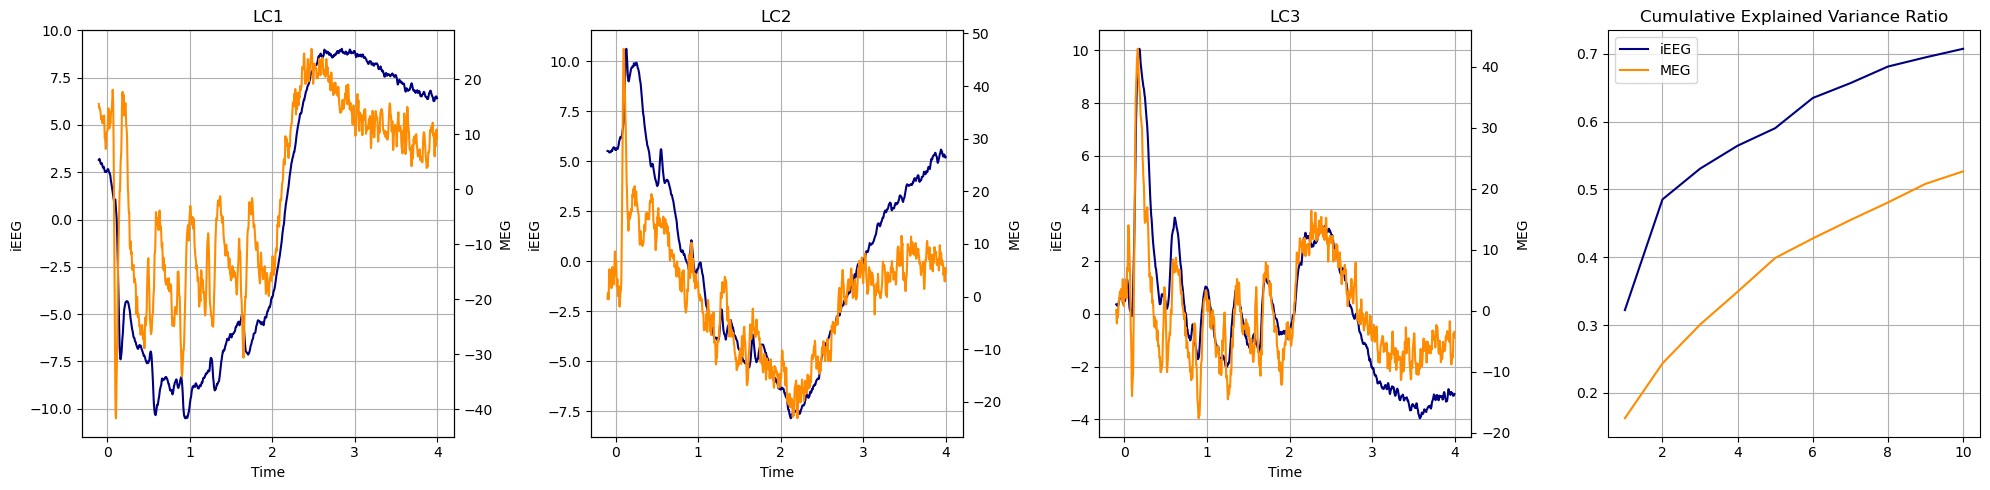

In [40]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

lab_compare = ['iEEG', 'MEG']

# First 3 panels: Xcca and Ycca on twin y-axes
for j in range(3):
    ax[j].plot(
        time_ieeg, Xcca[:, j],
        c=c_compare[0],
        label='Xcca'
    )
    
    ax2 = ax[j].twinx()
    ax2.plot(
        time_ieeg, Ycca[:, j],
        c=c_compare[1],
        label='Ycca'
    )

    ax[j].set_title('LC' + str(j + 1))
    ax[j].set_xlabel('Time')
    ax[j].set_ylabel('iEEG')
    ax2.set_ylabel('MEG')

    ax[j].grid()

# Explained variance
for ti, pc in enumerate(['X', 'Y']):
    ax[3].plot(
        np.arange(1, len(df_res['explained_' + pc]) + 1),
        df_res['explained_' + pc],
        c=c_compare[ti],
        label=lab_compare[ti]
    )

ax[3].set_title('Cumulative Explained Variance Ratio')
ax[3].legend()
ax[3].grid()

fig.tight_layout()

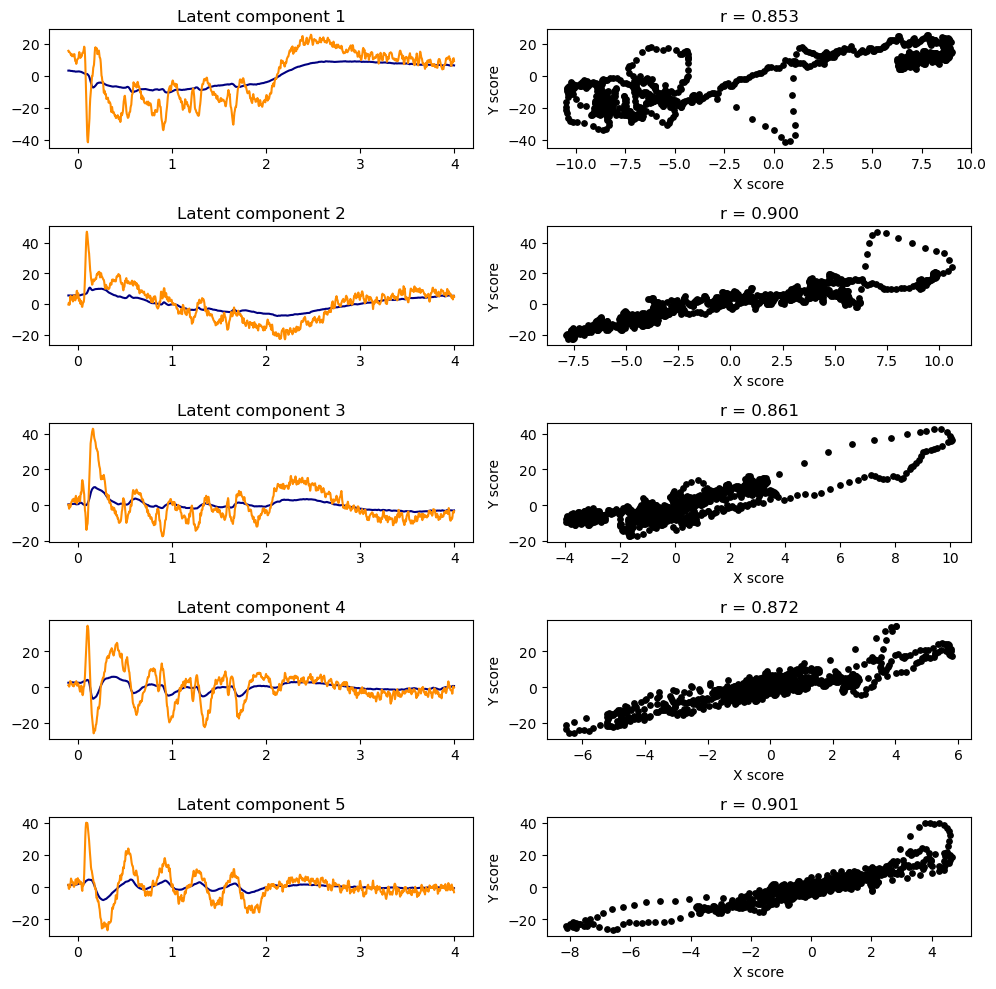

In [41]:
fig, axes = plt.subplots(5, 2, figsize=(10, nb_compo))

for i in range(5):
    axes[i,0].plot(time_ieeg, Xcca[:,i], label="X", c=c_compare[0])
    axes[i,0].plot(time_ieeg, Ycca[:,i], label="Y", c=c_compare[1])
    axes[i,0].set_title(f"Latent component {i+1}")

    axes[i,1].scatter(Xcca[:,i], Ycca[:,i], s=15, c='k')
    axes[i,1].set_xlabel("X score")
    axes[i,1].set_ylabel("Y score")
    axes[i,1].set_title(f"r = {df_res.loc[i , 'correlation']:.3f}")

plt.tight_layout()

In [42]:
x_loadings= cca_model.x_weights_ #x_loadings_
y_loadings =cca_model.y_weights_ #y_loadings_

In [51]:
df_ieeg = pd.DataFrame(np.abs(x_loadings))
df_ieeg['region'] = regions_ieeg
df_meg = pd.DataFrame(np.abs(y_loadings))
df_meg['region'] = regions_meg_match#*32 #regions_ieeg #regions_meg

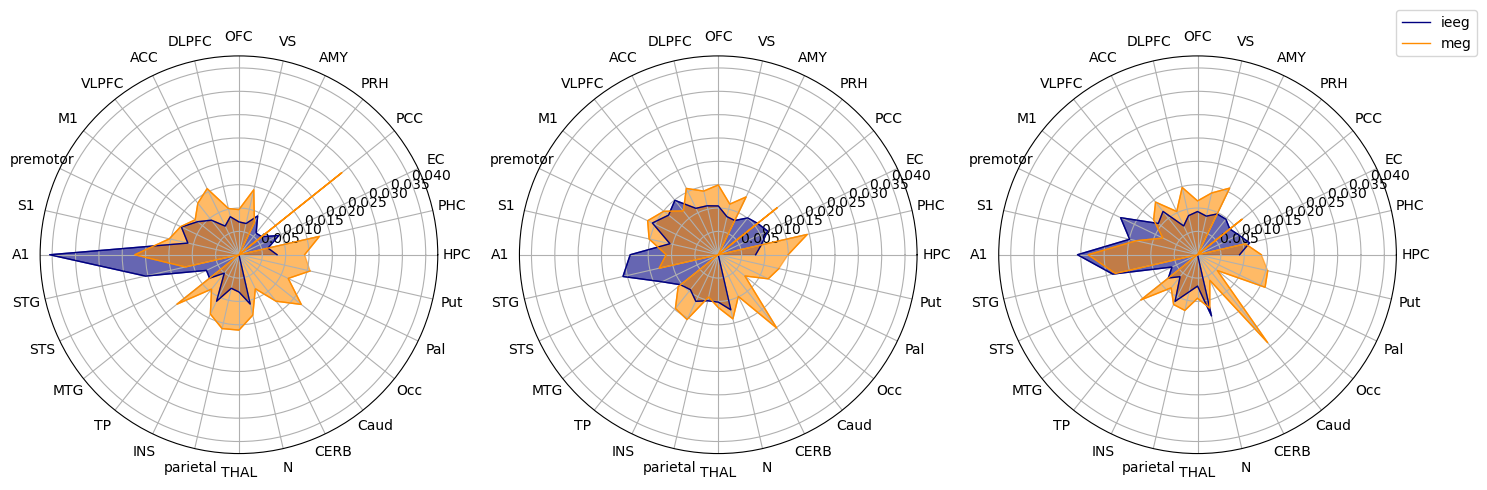

In [52]:
fig, ax = plt.subplots(1, 3, subplot_kw={"projection": "polar"}, figsize=(15, 15), sharey=True)
namr=['ieeg', 'meg']
for c in range(3):
    for i, df in enumerate([df_ieeg, df_meg]):
        df_compo = df[[c, 'region']]
        df_compo.loc[:, c] = df_compo[c].apply(lambda x : abs(x))
        mean_ = (df_compo.groupby("region")[c].median().reindex(list(COL_REG.keys()), fill_value=0).to_frame())
        angles = np.linspace(0, 2*np.pi, len(list(COL_REG.keys())), endpoint=False)
        ax[c].plot(angles,mean_[c].values,linewidth=1,color=c_compare[i], label=namr[i])
        ax[c].fill(angles,mean_[c].values,alpha=0.6,color=c_compare[i])
        ax[c].set_xticks(angles)
        ax[c].set_xticklabels(list(COL_REG.keys()), rotation=90)
        #ax[c].set_yticklabels([])
        #ax[c].set_ylim(0, 0.003)

ax[c].legend(loc=(1, 1))
plt.tight_layout()

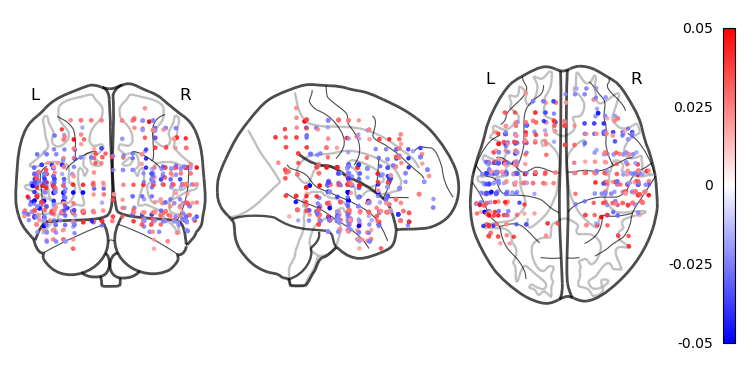

In [57]:
thr = CompoThr(y_loadings.T).T
mask_thr=np.where(abs(thr[:, 2]) >0, True, False)
plotting.plot_markers(thr[mask_thr, 2], pos_match[mask_thr]*1000,node_cmap='bwr', node_size=5, node_vmin=-0.05, node_vmax=0.05)

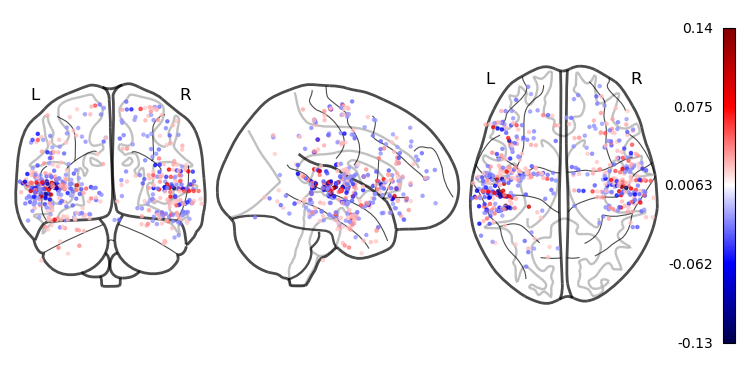

In [58]:
thr = CompoThr(x_loadings.T).T
mask_thr=np.where(abs(thr[:, 0]) >0, True, False)
plotting.plot_markers(thr[mask_thr, 0], coord[mask_thr]*1000,node_cmap='seismic', node_size=5) #, node_vmax=0.15)

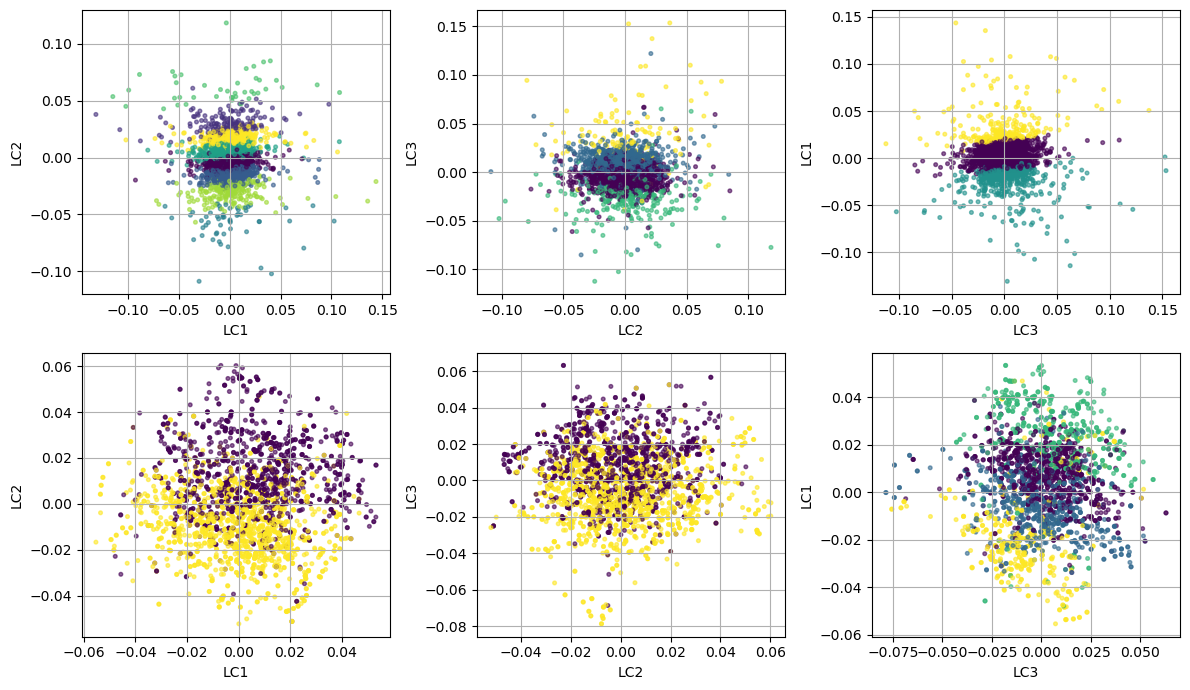

In [60]:
# analysis weights
fig, ax=plt.subplots(2, 3, figsize=(12, 7))
for a in ax.flatten():
    a.grid()

thr_x =x_loadings.T #[:, sorted_idx] #np.abs(CompoThr(x_loadings.T))#[:, sorted_idx]
thr_y =y_loadings.T #[:, sorted_idx] #np.abs(CompoThr(y_loadings.T))#[:, sorted_idx]


for axi, (i,j) in enumerate([(0, 1), (1, 2), (2, 0)]) :
    ax[0][axi].scatter(thr_x[i, :], thr_x[j, :], s=7, alpha = 0.6, c=df_label[f'ieeg_pc{j}'].values) # df_label[f'ieeg_pc{j}'].values np.array([COL_REG[r] for r in regions_ieeg])) #['pink']*ieeg_scaled.shape[0]) #
    ax[1][axi].scatter(thr_y[i, :], thr_y[j, :], s=7, alpha = 0.6,c= df_label_meg[f'meg_pc{j}'].values) # df_label[f'meg_pc{j}'].values np.array([COL_REG[r] for r in regions_meg_match])) #  ['green']*meg_scaled.shape[0]) 
    for k in range(2):
        ax[k][axi].set_ylabel(f'LC{j+1}')
        ax[k][axi].set_xlabel(f'LC{i+1}')

plt.tight_layout()

/tmp/ipykernel_26848/1939940959.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[axi].legend()


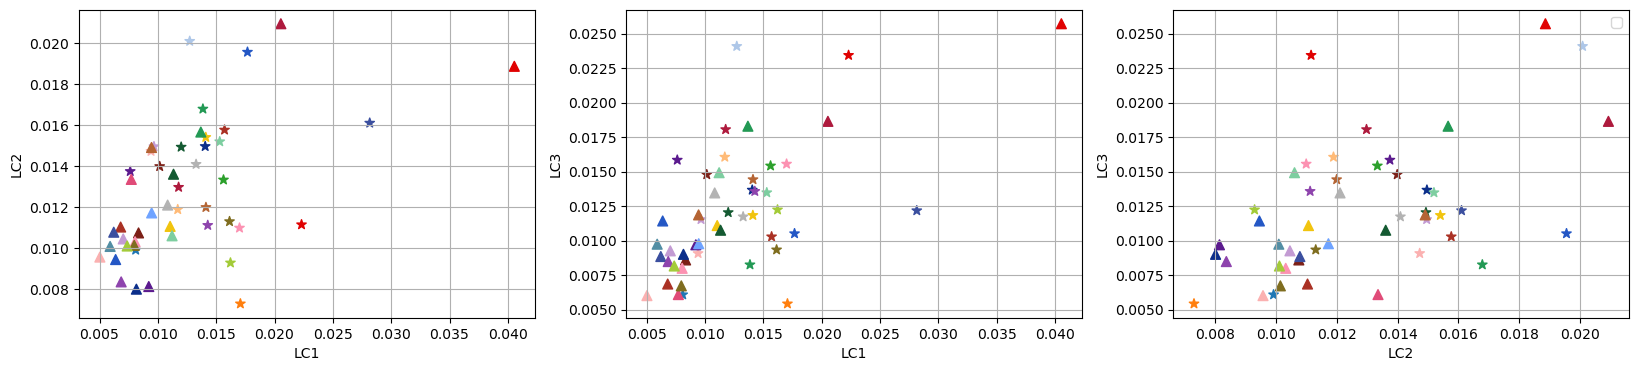

In [61]:
fig, ax=plt.subplots(1, 3, figsize=(20, 4))

for a in ax:
    a.grid()

for axi, (i,j) in enumerate([(0, 1), (0, 2), (1, 2)]) :
    
    ax[axi].scatter(df_meg.groupby('region').median().loc[:, i], df_meg.groupby('region').median().loc[:, j], c=[COL_REG[r] for r in df_meg.groupby('region').mean().index], s=50,  marker='*')
    ax[axi].scatter(df_ieeg.groupby('region').median().loc[:, i], df_ieeg.groupby('region').median().loc[:, j], c=[COL_REG[r] for r in df_ieeg.groupby('region').mean().index], s=50, marker='^')
    
    ax[axi].set_ylabel(f'LC{j+1}')
    ax[axi].set_xlabel(f'LC{i+1}')

ax[axi].legend()

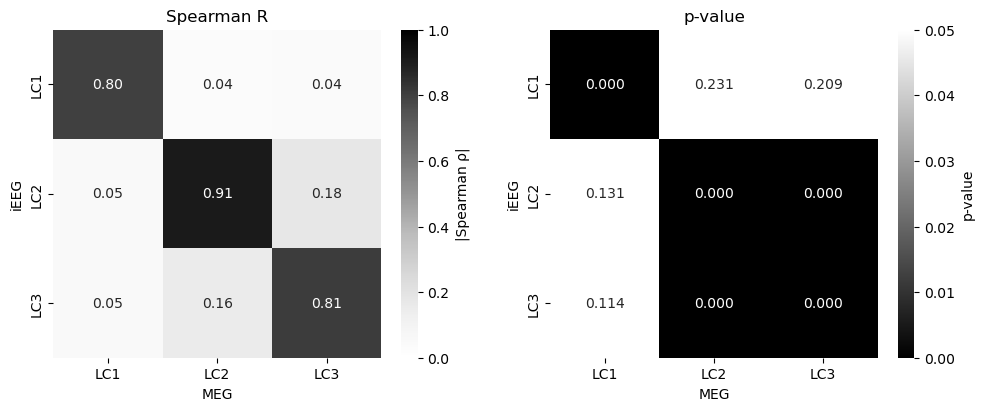

In [65]:
spearmr = np.zeros((3, 3))
speamp = np.zeros((3, 3))

for i in range(3):
    for j in range(3):
        spearmr[i, j], speamp[i, j] = spearmanr(Xcca[:, i], Ycca[:, j])

fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

sns.heatmap(abs(spearmr), ax=ax[0], cmap="Greys", vmin=0, vmax=1, annot=True, fmt=".2f", square=True, cbar_kws={"label": "|Spearman ρ|"})
sns.heatmap(speamp, ax=ax[1], cmap="grey", vmin=0, vmax=0.05, annot=True, fmt=".3f", square=True, cbar_kws={"label": "p-value"})

for a in ax:
    a.set_xlabel("MEG")
    a.set_ylabel("iEEG")
    a.set_xticklabels([f"LC{i+1}" for i in range(3)])
    a.set_yticklabels([f"LC{i+1}" for i in range(3)])

ax[0].set_title("Spearman R")
ax[1].set_title("p-value")

plt.show()

In [88]:
# Compare w with MEG original PCA
with open('out/meg_data_source.p', "rb") as f:
    meg_data = pickle.load(f) 

pca= PCA(3)
pca.fit(meg_data.mean(0).mean(0).T)
wmeg= pca.components_

V_pls =   y_loadings[:, :3].T
V_pca  = wmeg

In [101]:
from scipy.linalg import subspace_angles

angles = subspace_angles(V_pls, V_pca)
print("Principal angles (deg):", np.degrees(angles)) 

Principal angles (deg): [9.88673922e-15 5.11590720e-15 4.39077668e-45]


In [ ]:

spearmr = np.zeros((3, 3))
speamp = np.zeros((3, 3))

for i in range(3):
    for j in range(3):
        spearmr[i, j], speamp[i, j] = spearmanr(V_pls[i,:], V_pca[j,:])

fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

sns.heatmap(abs(spearmr), ax=ax[0], cmap="Greys", vmin=0, vmax=1, annot=True, fmt=".2f", square=True, cbar_kws={"label": "|Spearman ρ|"})
sns.heatmap(speamp, ax=ax[1], cmap="grey", vmin=0, vmax=0.05, annot=True, fmt=".3f", square=True, cbar_kws={"label": "p-value"})

for a in ax:
    a.set_xlabel("Component meg")
    a.set_ylabel("Component ieeg")

ax[0].set_title("Spearman R")
ax[1].set_title("p-value")


# projection-matrix distance


In [24]:
# handmade
model='PLSSVD_handmade'
file=f'out/cross_models_scale_{scaled_}/{model}_Ux.p'
with open(file, "rb") as f:
    Ux = pickle.load(f)

file=f'out/cross_models_scale_{scaled_}/{model}_UyT.p'
with open(file, "rb") as f:
    UyT = pickle.load(f)

df_res=pd.read_csv(f'out/cross_models_scale_{scaled_}/{model}_expl_var.csv')
df_res

FileNotFoundError: [Errno 2] No such file or directory: 'out/cross_models_scale_False/PLSSVD_handmade_Ux.p'

Text(0.5, 1.0, 'Individual Cum Var Expl')

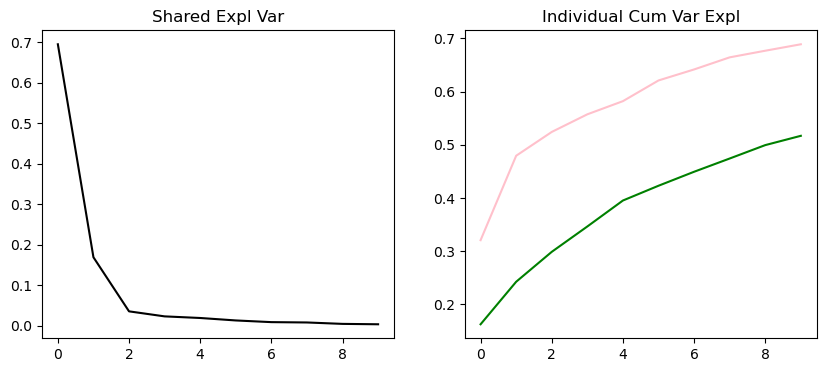

In [ ]:
fig, ax=plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(df_res['cum_expl_var'], c='k')
ax[1].plot(df_res['explained_X'],c='pink', label='iEEG' )
ax[1].plot(df_res['explained_Y'],c='green', label='MEG matched' )
ax[0].set_title('Shared Expl Var')
ax[1].set_title('Individual Cum Var Expl')

In [ ]:
X_ = ieeg_scaled.mean(0).T @ Ux[:, :10]
Y_ = meg_scaled.T @ UyT.T[:, :10]

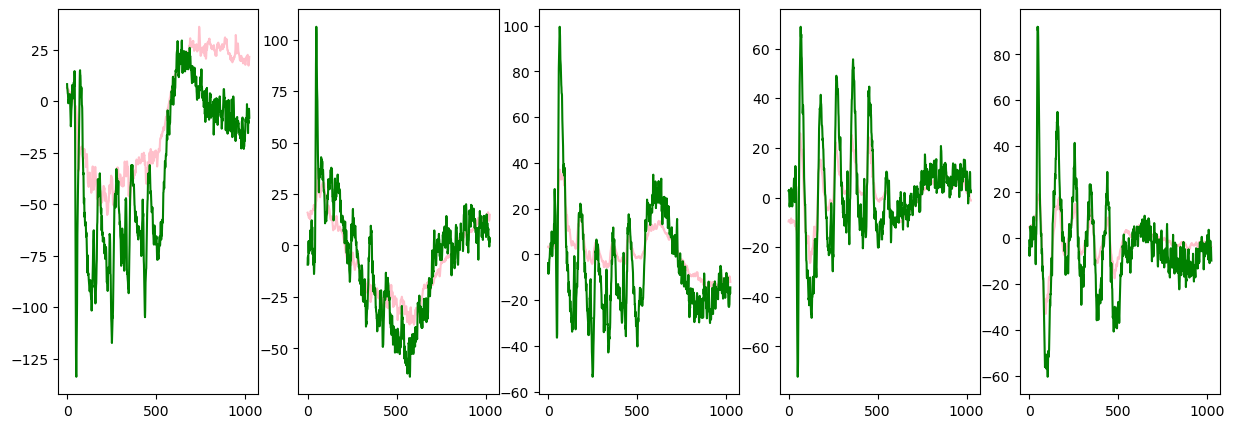

In [ ]:
fig, ax=plt.subplots(1, 5, figsize=(15, 5))
for c in range(5): 
    ax[c].plot(X_[:, c], c='pink')
    ax[c].plot(Y_[:, c], c='green')

In [ ]:
x_loadings= Ux[:, :10]
y_loadings =UyT.T[:, :10]

NameError: name 'Ux' is not defined

In [ ]:
df_ieeg = pd.DataFrame(np.abs(x_loadings))
df_ieeg['region'] = regions_ieeg
df_meg = pd.DataFrame(np.abs(y_loadings))
df_meg['region'] = regions_ieeg

NameError: name 'x_loadings' is not defined

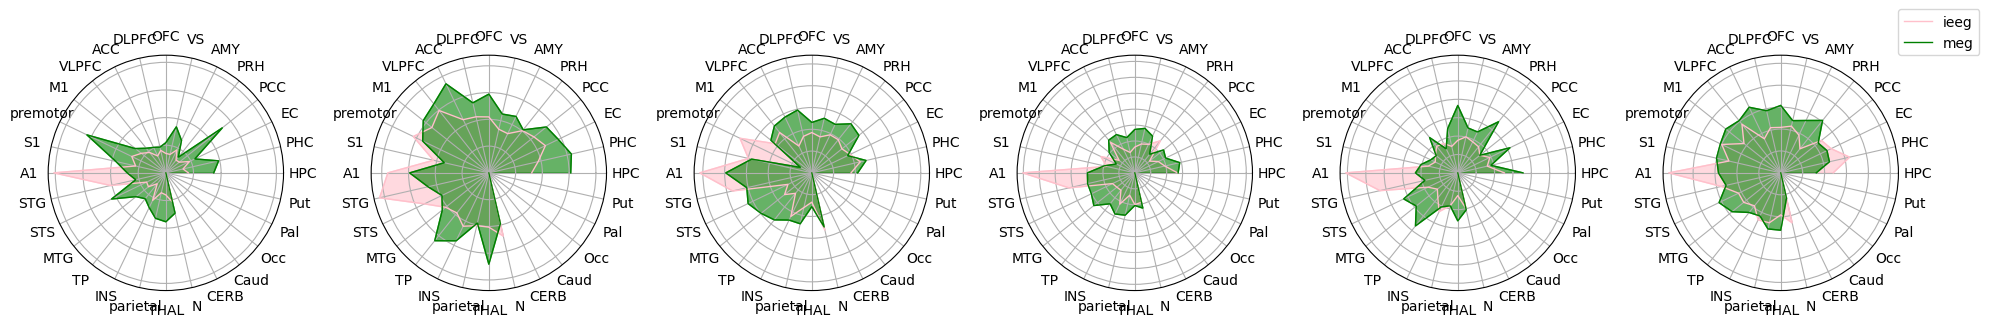

In [ ]:
fig, ax = plt.subplots(1, 6, subplot_kw={"projection": "polar"}, figsize=(20, 20))
colr=['pink', 'green']
namr=['ieeg', 'meg']
for c in range(6):
    for i, df in enumerate([df_ieeg, df_meg]):
        df_compo = df[[c, 'region']]
        df_compo.loc[:, c] = df_compo[c].apply(lambda x : abs(x))
        mean_ = (df_compo.groupby("region")[c].median().reindex(list(COL_REG.keys()), fill_value=0).to_frame())
        angles = np.linspace(0, 2*np.pi, len(list(COL_REG.keys())), endpoint=False)
        ax[c].plot(angles,mean_[c].values,linewidth=1,color=colr[i], label=namr[i])
        ax[c].fill(angles,mean_[c].values,alpha=0.6,color=colr[i])
        ax[c].set_xticks(angles)
        ax[c].set_xticklabels(list(COL_REG.keys()), rotation=90)
        ax[c].set_yticklabels([])

ax[c].legend(loc=(1, 1))
plt.tight_layout()

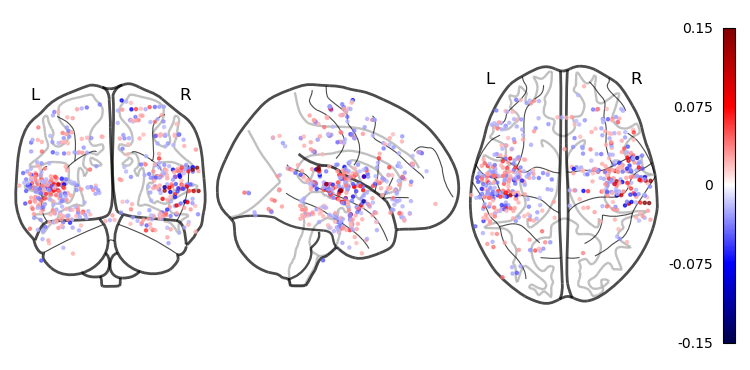

In [ ]:
thr = CompoThr(Ux[:, :10].T).T
mask_thr=np.where(np.abs(thr[:, 2]) >0, True, False)
plotting.plot_markers( thr[mask_thr, 2], coord[mask_thr]*1000,node_cmap='seismic', node_size=5, node_vmin = -0.15, node_vmax=0.15)

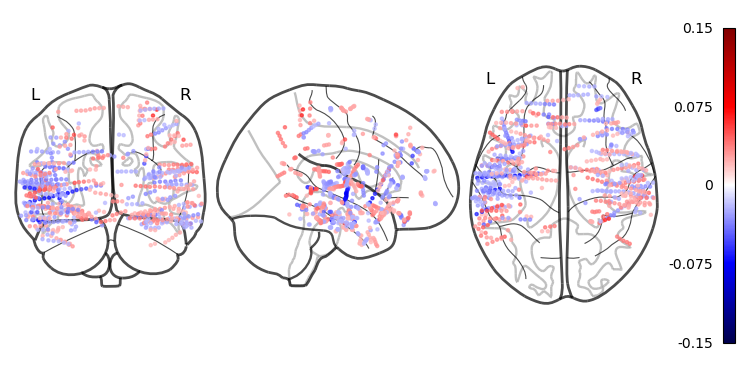

In [ ]:
thr = CompoThr(UyT.T[:, :10].T).T
mask_thr=np.where(abs(thr[:, 2]) >0, True, False)
plotting.plot_markers( thr[mask_thr, 2], coord[mask_thr]*1000,node_cmap='seismic', node_size=5, node_vmin = -0.15, node_vmax=0.15)

NameError: name 'x_loadings' is not defined

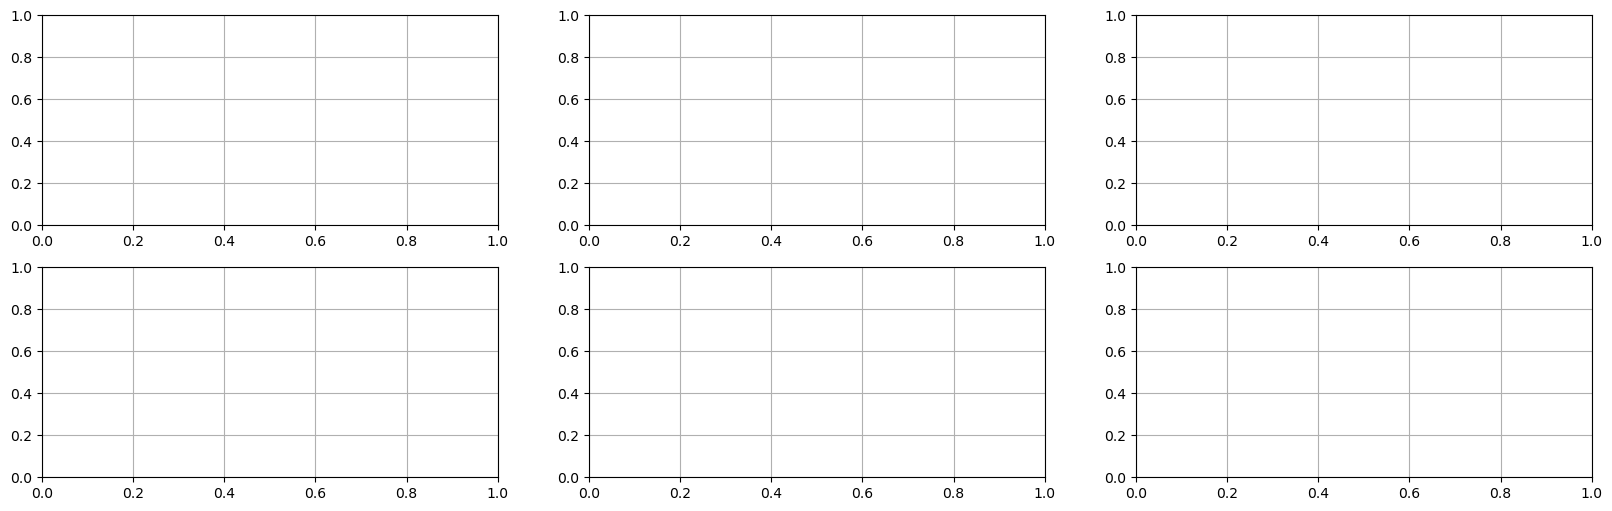

In [ ]:
# analysis weights
fig, ax=plt.subplots(2, 3, figsize=(20, 6))
for a in ax.flatten():
    a.grid()

thr_x=x_loadings.T #np.abs(CompoThr(x_loadings.T))#[:, sorted_idx]
thr_y =y_loadings.T #np.abs(CompoThr(y_loadings.T))#[:, sorted_idx]

for axi, (i,j) in enumerate([(0, 1), (1, 2), (2, 0)]) :
    ax[0][axi].scatter(thr_x[i, :], thr_x[j, :], marker='^', s=15, alpha = 0.9, c= df_label[f'ieeg_pc{j}']) # df_label[f'ieeg_pc{j}'].values np.array([COL_REG[r] for r in regions_ieeg])) #['pink']*ieeg_scaled.shape[0]) #
    ax[1][axi].scatter(thr_y[i, :], thr_y[j, :], marker='*',s=15, alpha = 0.4,c=  df_label[f'meg_pc{j}']) # df_label[f'meg_pc{j}'].values np.array([COL_REG[r] for r in regions_meg_match])) #  ['green']*meg_scaled.shape[0]) 
    for k in range(2):
        ax[k][axi].set_ylabel(f'PC{j+1}')
        ax[k][axi].set_xlabel(f'PC{i+1}')

/tmp/ipykernel_24302/777486226.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[axi].legend()


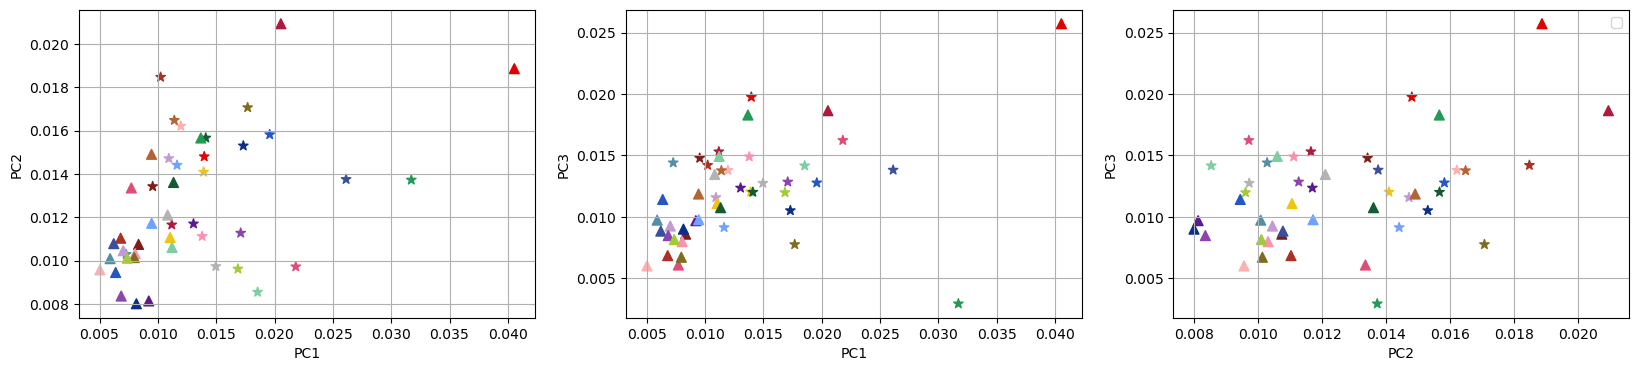

In [ ]:
fig, ax=plt.subplots(1, 3, figsize=(20, 4))

for a in ax:
    a.grid()

for axi, (i,j) in enumerate([(0, 1), (0, 2), (1, 2)]) :
    
    ax[axi].scatter(df_meg.groupby('region').median().loc[:, i], df_meg.groupby('region').median().loc[:, j], c=[COL_REG[r] for r in df_meg.groupby('region').mean().index], s=50,  marker='*')
    ax[axi].scatter(df_ieeg.groupby('region').median().loc[:, i], df_ieeg.groupby('region').median().loc[:, j], c=[COL_REG[r] for r in df_ieeg.groupby('region').mean().index], s=50, marker='^')
    
    ax[axi].set_ylabel(f'PC{j+1}')
    ax[axi].set_xlabel(f'PC{i+1}')

ax[axi].legend()

In [ ]:
# For PLS Regression
#The coefficients of the linear model such that y is approximated as y = X @ coef_.T + intercept_.
Y_tile = ieeg_scaled.T @ cca_model.coef_.T  + cca_model.intercept_
print(cca_model.score(ieeg_scaled.T, meg_scaled.T))

fig = plt.figure()
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection='polar')

diff=Y_tile.T - meg_scaled
ax1.plot(abs(diff).mean(0))


df=pd.DataFrame(abs(diff).mean(1))
df['regions'] = regions_ieeg
angles = np.linspace(0, 2*np.pi, len(np.unique(regions_ieeg)), endpoint=False)
ax2.plot(angles,df.groupby('regions')[0].mean().values,linewidth=1)
ax2.fill(angles,df.groupby('regions')[0].mean().values,alpha=0.2)
ax2.set_xticks(angles)
ax2.set_xticklabels(df.groupby('regions')[0].mean().index, rotation=90)

ax1.grid()

fig.suptitle('Distance between projection and true data')


AttributeError: 'PLSSVD' object has no attribute 'coef_'